In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Load the data
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(url, names=columns)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [10]:
#Target
#df["Outcome"]
print(df["Outcome"].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


In [16]:
#Dataset dimensions
df.shape
#Inspect the data types
df.info()

#basic statistics
df.describe()

#Check missing values
df.isnull().sum()

#Some medical measurements contain 0, 
#even though 0 isn't physiologically realistic for those measurements
#A zero glucose measurement in this dataset is generally treated 
#as a missing/invalid measurement not a genuine measurement of zero

(df == 0).sum() #Tell us how many zero values exist in every column

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [16]:
#Identify invalid zeros
zero_columns =[
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]
(df[zero_columns] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

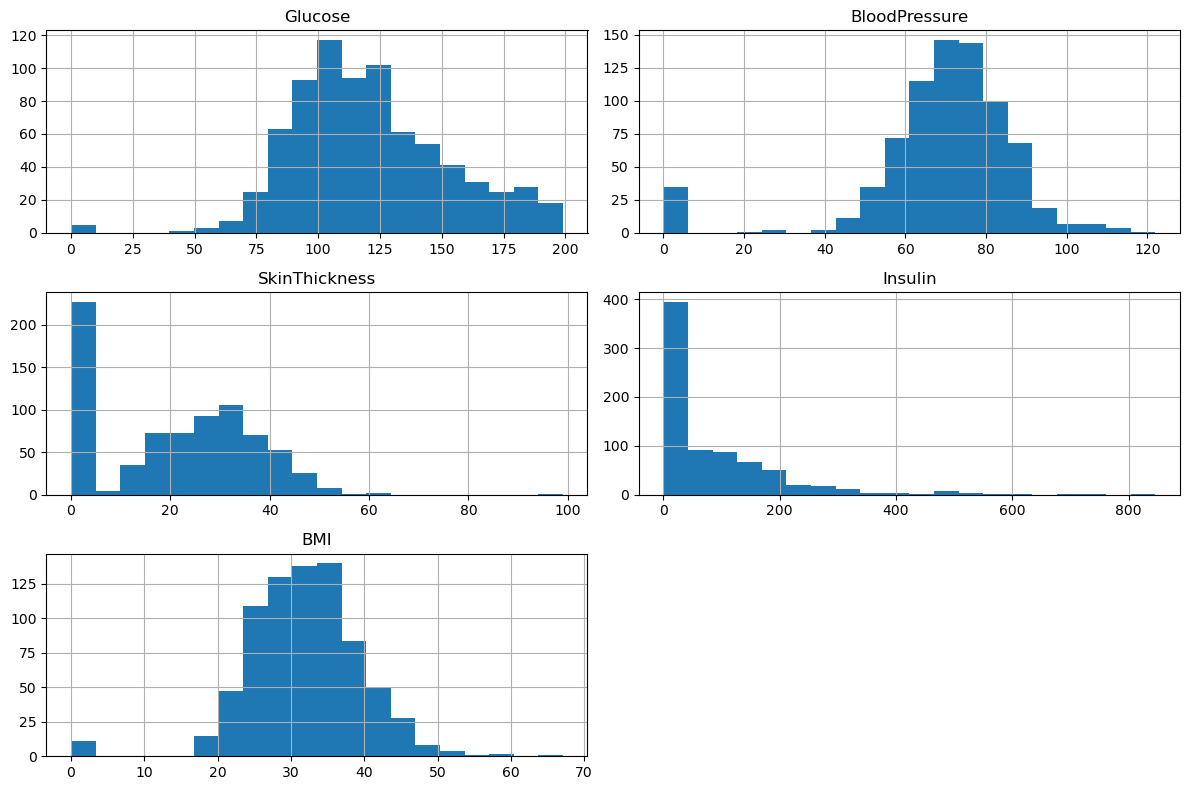

<Figure size 640x480 with 0 Axes>

In [23]:
#See the distribution first
df[zero_columns].hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()
plt.savefig("../reports/distributions.png")

Counts:
Outcome
0    500
1    268
Name: count, dtype: int64

Percentages:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


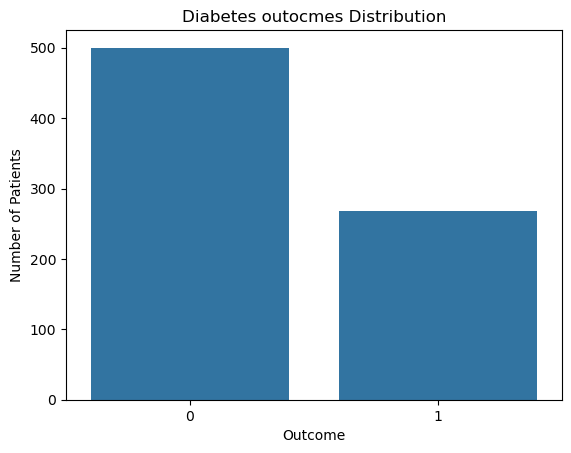

In [25]:
#Explore diabetes by outcome
#Do the feature values look different between 
#patients with and without diabetes?
sns.countplot(data = df,x="Outcome")
plt.title("Diabetes outocmes Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

#Calculate percentages
outcome_counts = df["Outcome"].value_counts()

outcome_percentages = df["Outcome"].value_counts(normalize=True) * 100

print("Counts:")
print(outcome_counts)

print("\nPercentages:")
print(outcome_percentages)
plt.show()
              

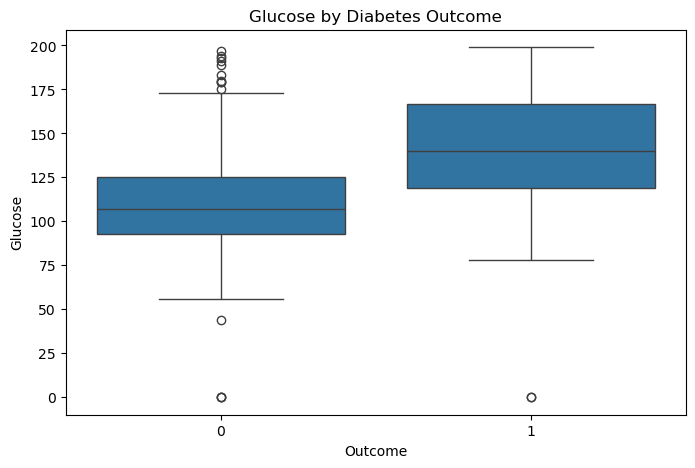

In [26]:
#Compare glucose
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Outcome", y="Glucose")

plt.title("Glucose by Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Glucose")

plt.show()

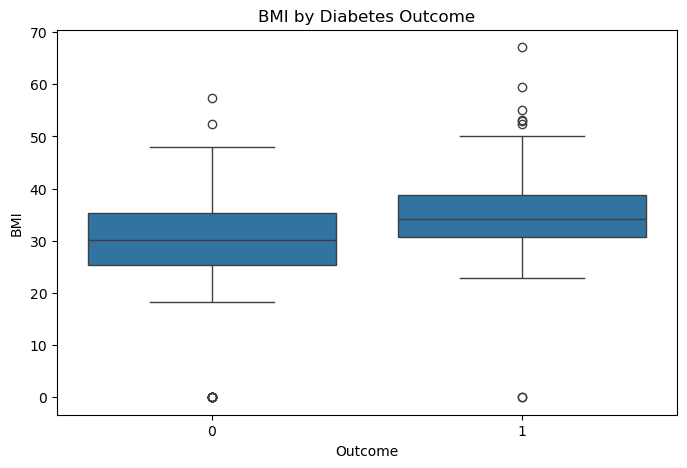

In [27]:
#Compare BMI
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Outcome", y="BMI")

plt.title("BMI by Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("BMI")

plt.show()

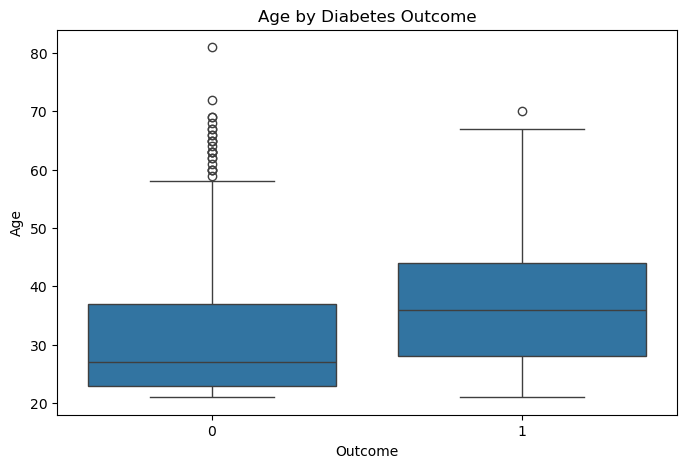

In [28]:
#Compare Age
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Outcome", y="Age")

plt.title("Age by Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Age")

plt.show()

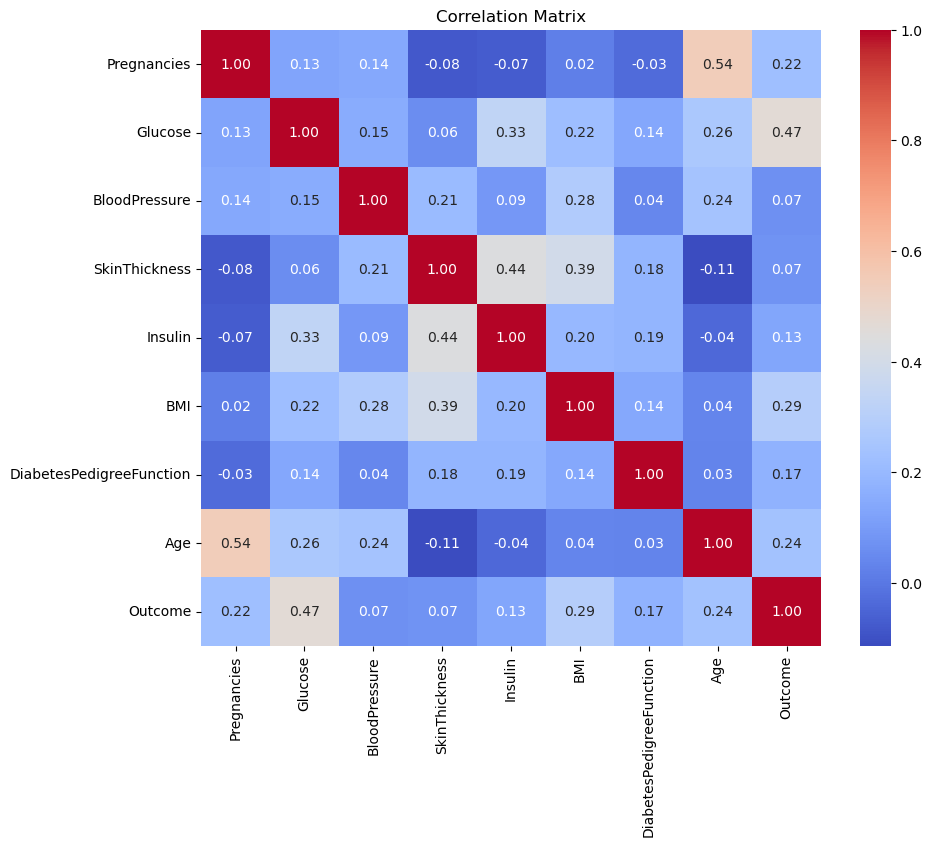

In [31]:
#Correlation Analysis
correlation_matrix = df.corr()
correlation_matrix

#Visualize the correlations
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.savefig("../reports/correlation_matrix.png")
plt.show()

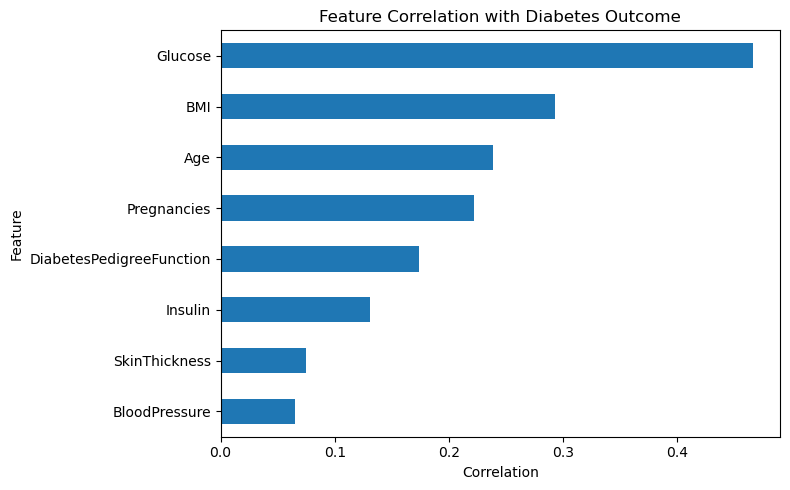

In [33]:
#Sort correlations with Outcome
outcome_correlations =(
    correlation_matrix["Outcome"].sort_values(ascending=False)
)
outcome_correlations

#Visualize feature correlations with the target
plt.figure(figsize=(8, 5))

outcome_correlations.drop("Outcome").sort_values().plot(kind="barh")

plt.title("Feature Correlation with Diabetes Outcome")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [5]:
#Separate features and target
X = df.drop("Outcome",axis=1)
y = df["Outcome"]

print("X shape:",X.shape)
print("y shape:",y.shape)

X shape: (768, 8)
y shape: (768,)


In [9]:
#Split into training and testing data
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
#Verify the split
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 614
Testing samples: 154

Training target distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Testing target distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [11]:
#BUILD THE PREPROCESSING PIPELINE

#import the preprocessing tools
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [13]:
#Create a preprocessing pipeline
preprocessing_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
preprocessing_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account fo

In [18]:
#Create a copy of the trainin and test data
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

#replace zeros only in the appropriate columns
X_train_processed[zero_columns] = (
    X_train_processed[zero_columns].replace(0,np.nan)
)
X_test_processed[zero_columns] = (
    X_test_processed[zero_columns].replace(0, np.nan)
)
#X_train_processed
X_test_processed

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
44,7,159.0,64.0,NaN,NaN,27.4,0.294,40
672,10,68.0,106.0,23.0,49.0,35.5,0.285,47
700,2,122.0,76.0,27.0,200.0,35.9,0.483,26
630,7,114.0,64.0,NaN,NaN,27.4,0.732,34
81,2,74.0,NaN,NaN,NaN,NaN,0.102,22
...,...,...,...,...,...,...,...,...
32,3,88.0,58.0,11.0,54.0,24.8,0.267,22
637,2,94.0,76.0,18.0,66.0,31.6,0.649,23
593,2,82.0,52.0,22.0,115.0,28.5,1.699,25
425,4,184.0,78.0,39.0,277.0,37.0,0.264,31


In [19]:
#Fit the preprocessing pipeline using training data
X_train_scaled = preprocessing_pipeline.fit_transform(
    X_train_processed
)
#Transform the test data
X_test_scaled = preprocessing_pipeline.transform(X_test_processed)

#Check the resulting shapes
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (614, 8)
X_test_scaled shape: (154, 8)


In [20]:
#Check the scaled training data
X_train_scaled[:5]

array([[-0.85135507, -1.05642747, -0.82674004, -1.91818693, -1.20336073,
        -0.76969431,  0.31079384, -0.79216928],
       [ 0.35657564,  0.14439907,  0.47777235, -0.22987447, -1.47019479,
        -0.41771394, -0.11643851,  0.56103382],
       [-0.5493724 , -0.55608308, -1.15286813,  1.23332967, -0.55533518,
         0.35957603, -0.76486207, -0.70759409],
       [-0.85135507,  0.81152492, -1.31593218, -0.00476614, -0.16143729,
        -0.40304809,  0.26231357, -0.36929331],
       [-1.15333775, -0.88964601, -0.66367599,  1.12077551, -0.41556496,
         1.78216334, -0.33762972, -0.96131967]])

In [21]:
#Train Logistic
from sklearn.linear_model import LogisticRegression

In [23]:
#Create the model
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

#Train the model
logistic_model.fit(X_train_scaled,y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [24]:
#Make predictions
y_pred = logistic_model.predict(X_test_scaled)

#Look at some predictions
print("First 20 predictions:")
print(y_pred[:20])
print("\nFirst 20 actual values:")
print(y_test.values[:20])

#Check the number of predictions
print("Number of predictions:", len(y_pred))
print("Number of test samples:", len(y_test))


First 20 predictions:
[1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0]

First 20 actual values:
[0 0 0 1 0 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0]
Number of predictions: 154
Number of test samples: 154


In [25]:
#Evaluate Logistic Regression
#import the metrics
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [26]:
#How many the algorithm classify correctly ?
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy 0.7077922077922078


In [29]:
#Percentage of predicted positives
precision = precision_score(y_test,y_pred)
print("Precision:",precision)

Precision: 0.6


In [32]:
#Recall
recall = recall_score(y_test,y_pred)
print("Recall:",recall)

#F1
f1 = f1_score(y_test, y_pred)
print("F1-score:", f1)

Recall: 0.5
F1-score: 0.5454545454545454


In [33]:
#Confusion Matrix
#Seeing exactly what the model got right and wrong
from sklearn.metrics import confusion_matrix

In [34]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[82, 18],
       [27, 27]])

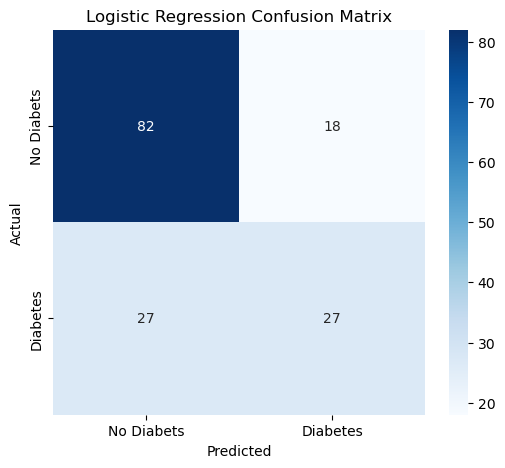

In [36]:
#Visualize the confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabets","Diabetes"],
    yticklabels=["No Diabets","Diabetes"]
)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../reports/confusion_matrix.png")
plt.show()

In [37]:
print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

Logistic Regression Results
---------------------------
Accuracy : 0.7078
Precision: 0.6000
Recall   : 0.5000
F1-score : 0.5455

Confusion Matrix:
[[82 18]
 [27 27]]


In [39]:
#Random Forest:
from sklearn.ensemble import RandomForestClassifier
random_forest_model = RandomForestClassifier(
    n_estimators = 300, #300decision trees
    random_state=42, #make result reproducible
    n_jobs=-1 # Uses all availabe CPU cores to speed up training
)

#Create a separate imputer:
rf_imputer = SimpleImputer(strategy="median")
X_train_rf = rf_imputer.fit_transform(X_train_processed)
X_test_rf = rf_imputer.transform(X_test_processed)
#Train the model
random_forest_model.fit(X_train_rf,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [43]:
#Generate predictions
rf_predictions = random_forest_model.predict(X_test_rf)

print("First 20 Random Forest predictions:")
print(rf_predictions[:20])

First 20 Random Forest predictions:
[1 0 0 0 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0]


In [44]:
#Evaluate it
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("Random Forest Results")
print("--------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-score : {rf_f1:.4f}")

Random Forest Results
--------------------
Accuracy : 0.7403
Precision: 0.6591
Recall   : 0.5370
F1-score : 0.5918


In [45]:
#Calculate the random forest confusion matrix
rf_cm = confusion_matrix(y_test, rf_predictions)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[85 15]
 [25 29]]


In [46]:
#Compare it with Logistic Regression
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ]
})

comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.707792,0.740260
1,Precision,0.600000,0.659091
2,Recall,0.500000,0.537037
3,F1-score,0.545455,0.591837


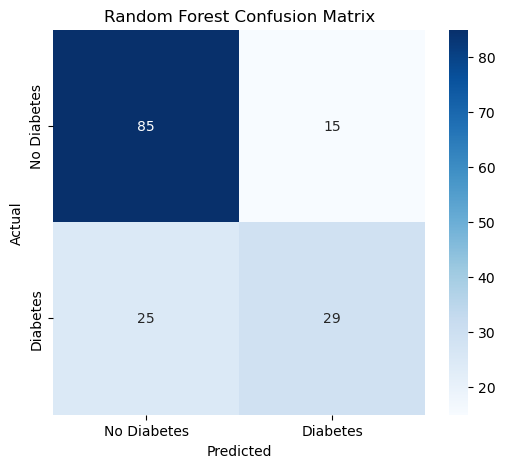

True Negatives : 85
False Positives: 15
False Negatives: 25
True Positives : 29


In [47]:
#Analyze the random forest confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

tn, fp, fn, tp = rf_cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

In [48]:
#Tune the random forest
from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_estimators": [100, 200, 300],#number of trees
    "max_depth": [None, 5, 10, 15], #maximum depth of each tree
    "min_samples_split": [2, 5, 10],#minimum samples required to split a node
    "min_samples_leaf": [1, 2, 4] #minimum samples allowed in a leaf
}
#Create the GridSearchCV
rf_for_tuning = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf_for_tuning,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [49]:
#Run the search
grid_search.fit(X_train_rf, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"

In [50]:
#See the best parameters
print("Best parameters:")
print(grid_search.best_params_)

print("Best cross-validation F1-score:")
print(grid_search.best_score_)

#Get the optimized model
best_rf_model = grid_search.best_estimator_

#Evaluate it on the test set:
best_rf_predictions = best_rf_model.predict(X_test_rf)

#Calculate the metrics
best_rf_accuracy = accuracy_score(y_test, best_rf_predictions)
best_rf_precision = precision_score(y_test, best_rf_predictions)
best_rf_recall = recall_score(y_test, best_rf_predictions)
best_rf_f1 = f1_score(y_test, best_rf_predictions)

print("Tuned Random Forest")
print("-------------------")
print(f"Accuracy : {best_rf_accuracy:.4f}")
print(f"Precision: {best_rf_precision:.4f}")
print(f"Recall   : {best_rf_recall:.4f}")
print(f"F1-score : {best_rf_f1:.4f}")

Best parameters:
{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation F1-score:
0.658573494283911
Tuned Random Forest
-------------------
Accuracy : 0.7532
Precision: 0.6739
Recall   : 0.5741
F1-score : 0.6200


In [51]:
#Compare all models
print("Model Comparison")
print("================")

print(f"Logistic Regression F1 : {f1_score(y_test, y_pred):.4f}")
print(f"Random Forest F1       : {f1_score(y_test, rf_predictions):.4f}")
print(f"Tuned Random Forest F1 : {best_rf_f1:.4f}")

Model Comparison
Logistic Regression F1 : 0.5455
Random Forest F1       : 0.5918
Tuned Random Forest F1 : 0.6200


In [54]:
#Analyze the tuned random forest
tuned_rf_cm = confusion_matrix(
    y_test,
    best_rf_predictions
)

print(tuned_rf_cm)

tn, fp, fn, tp = tuned_rf_cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

[[85 15]
 [23 31]]
True Negatives : 85
False Positives: 15
False Negatives: 23
True Positives  : 31


Glucose                     0.269102
BMI                         0.157928
DiabetesPedigreeFunction    0.125010
Age                         0.119767
Insulin                     0.091118
BloodPressure               0.083912
Pregnancies                 0.078996
SkinThickness               0.074168
dtype: float64


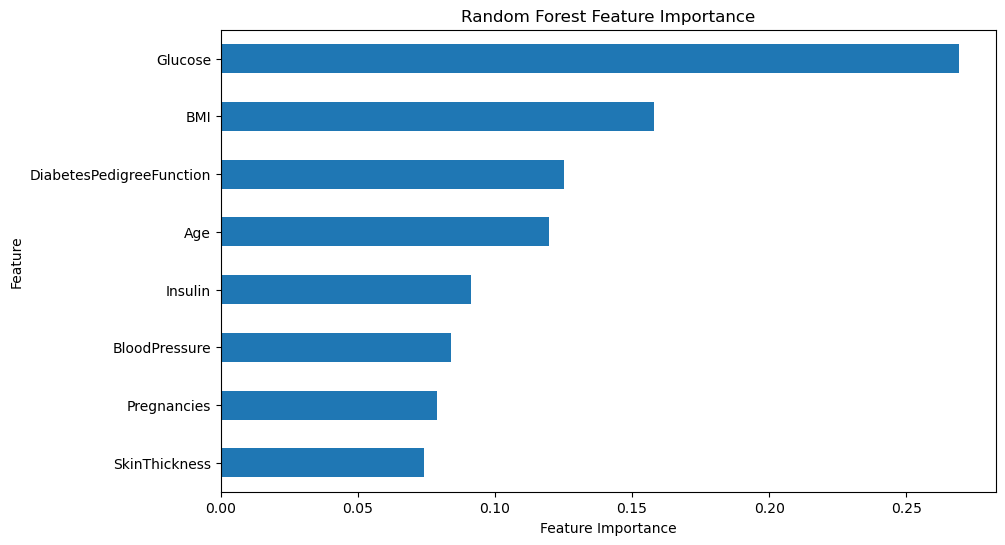

In [56]:
#Which features does our Random Forest consider most important 
#for predicting diabetes?

feature_importance = pd.Series(
    best_rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

#Visualize the importance

plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(
    kind="barh"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.show()

In [57]:
#Get the prediction probabilities
rf_probabilities = best_rf_model.predict_proba(X_test_rf)[:, 1]

print(rf_probabilities[:10])

[0.68458333 0.225      0.05736315 0.28102564 0.072      0.285
 0.48418421 0.715      0.07044444 0.81      ]


In [59]:
#Create predictions using a 0.50 threshold
threshold = 0.50

threshold_predictions = (
    rf_probabilities >= threshold
).astype(int)

print(np.array_equal(
    threshold_predictions,
    best_rf_predictions
))

True


In [64]:
#Test a lower threshold
threshold = 0.40
while threshold > 0.30:
    predictions_040_030 = (
        rf_probabilities >= threshold
    ).astype(int)
    
    print("Threshold: " ,threshold)
    print("----------------")
    
    print(f"Accuracy : {accuracy_score(y_test, predictions_040):.4f}")
    print(f"Precision: {precision_score(y_test, predictions_040):.4f}")
    print(f"Recall   : {recall_score(y_test, predictions_040):.4f}")
    print(f"F1-score : {f1_score(y_test, predictions_040):.4f}")
    threshold = threshold - 0.1

Threshold:  0.4
----------------
Accuracy : 0.7208
Precision: 0.5821
Recall   : 0.7222
F1-score : 0.6446
Threshold:  0.30000000000000004
----------------
Accuracy : 0.7403
Precision: 0.5921
Recall   : 0.8333
F1-score : 0.6923


In [65]:
#Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

#Create the baseline Decision tree

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

#Train it
decision_tree_model.fit(X_train_rf,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [70]:
#Make predictions
dt_predictions = decision_tree_model.predict(X_test_rf)

#Evaluate the Decision Tree
dt_accuracy = accuracy_score(
    y_test,
    dt_predictions
)

dt_precision = precision_score(
    y_test,
    dt_predictions
)

dt_recall = recall_score(
    y_test,
    dt_predictions
)

dt_f1 = f1_score(
    y_test,
    dt_predictions
)

print("Decision Tree")
print("-------------")
print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1-score : {dt_f1:.4f}")


Decision Tree
-------------
Accuracy : 0.6818
Precision: 0.5532
Recall   : 0.4815
F1-score : 0.5149


In [74]:
#Confusion Matrix
dt_cm =  confusion_matrix(y_test,dt_predictions)
print("Confusion Matrix:", dt_cm)
tn, fp, fn, tp = dt_cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

Confusion Matrix: [[79 21]
 [28 26]]
True Negatives : 79
False Positives: 21
False Negatives: 28
True Positives  : 26


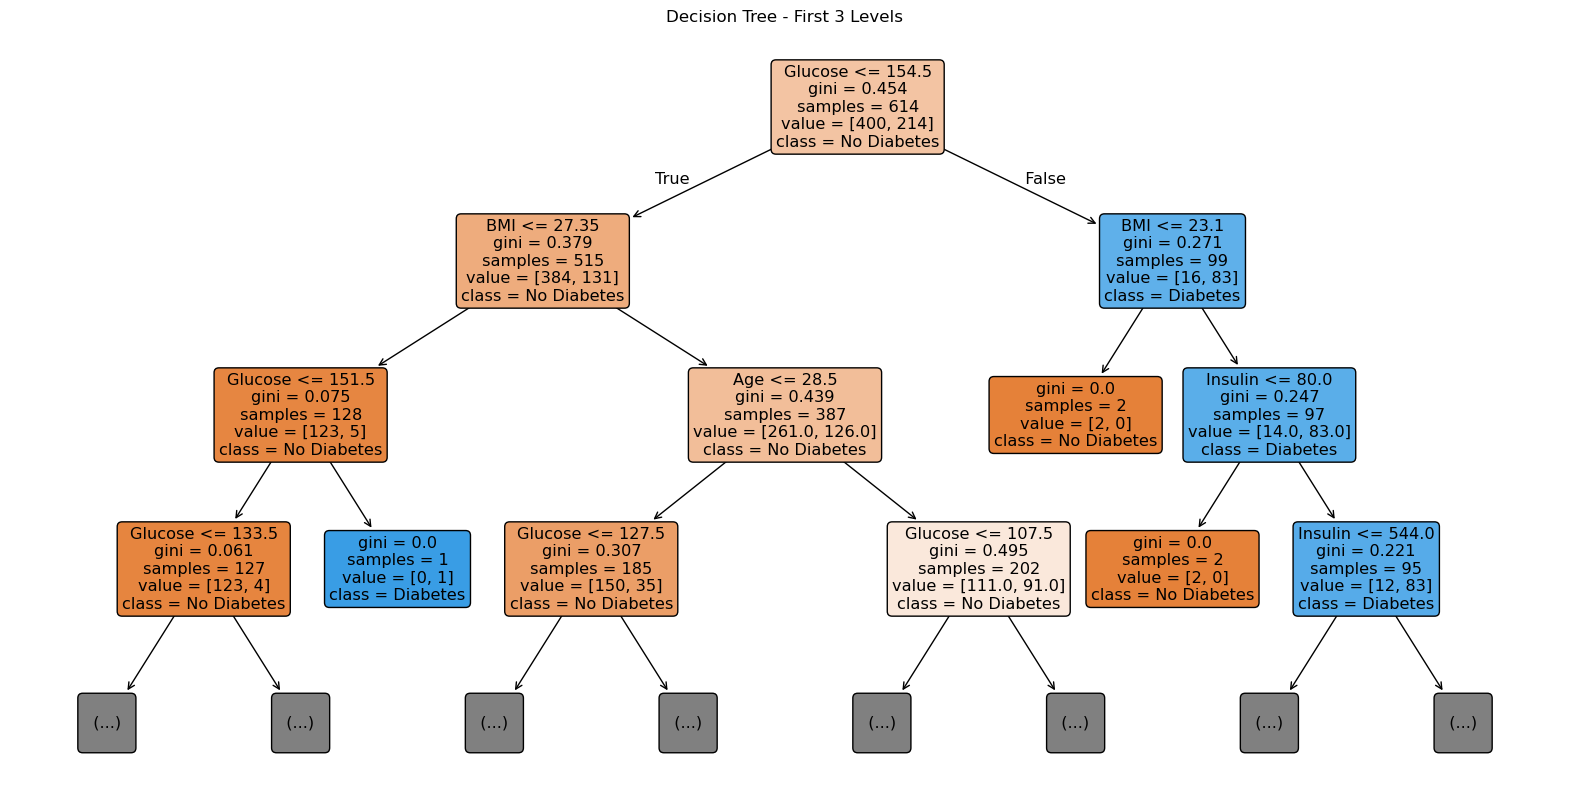

In [80]:
#Visualize the tree
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree_model,
    feature_names=X.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Decision Tree - First 3 Levels")
plt.savefig("../reports/decision_tree.png")
plt.show()

In [79]:
#Feature importance
dt_feature_importance = pd.Series(
    decision_tree_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(dt_feature_importance)

Glucose                     0.355518
BMI                         0.178572
Age                         0.127095
BloodPressure               0.097661
DiabetesPedigreeFunction    0.092002
Insulin                     0.069723
Pregnancies                 0.064105
SkinThickness               0.015325
dtype: float64
